TODO:

1. Satellites <br>
    a. <span style="color:green"> Create a 'scale' functionality to keep the aspect ratio of the components </span> <br> 
    b. <span style="color:green"> Create a "draw_footprint" function for the satellites to show illumination of the signal - this should take all objects into account I think? </span> <br>
2. Multipath <br>
    a. <span style="color:green"> Create functionality to draw a reflection from the ground in the draw_signal subfunction </span>
3. Ionosphere <br>
    a. <span style="color:green"> Create a class to draw 'ionospheric clouds' with a simple shape, which will then block signals </span>
4. Troposphere <br>
    a. Should there be the possibility to add a tropospheric layer, with either wet parts or dry parts?
5. Objects <br>
    a. Create a 'tree' class (should be a simple illustration) <br>
    b. <span style="color:red"> REDACTED - doing it differently </span> Create a 'base station' class (should be different from the receiver) <br>
    c. Create a 'drone receiver' class (should be a simple illustration) <br> 
    d. <span style="color:green"> Consider creating the ground as a class, so it can be a reflective surface (and perhabs make different types (like riverbank, common ground, etc.)) </span>
6. Receiver <br>
    a. <span style="color:green"> Implement a feature to add a text string to the receiver (e.g. *rover* or *basestation*) </span>

In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# link to colorscale for colorblind people:
# https://davidmathlogic.com/colorblind/#%23000000-%23E69F00-%2356B4E9-%23009E73-%23F0E442-%230072B2-%23D55E00-%23CC79A7

# gsi — Geodetic Scene Illustrator
from gsi import Receiver, Satellite, Blob, Ground, Building, Drone

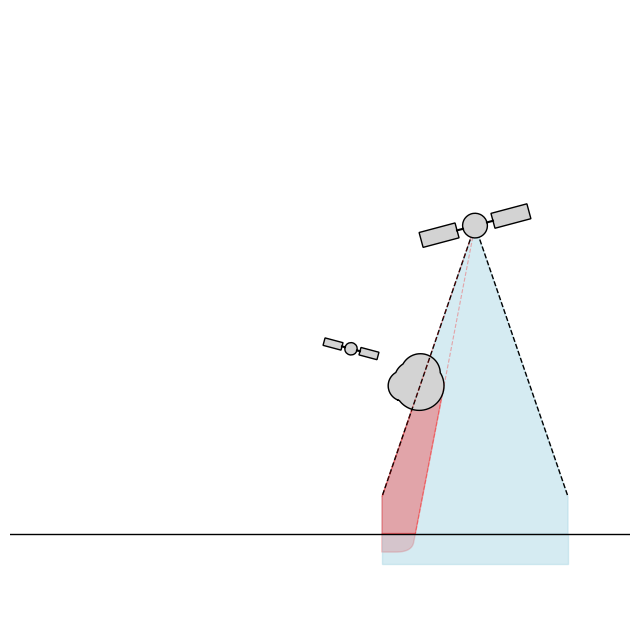

In [ ]:
ground = Ground(height=5)

satellite = Satellite(position=(25,55), rotation=15)
satellite2 = Satellite(position=(5,35), rotation=-15)

drone = Drone(position=(5,5))

blob = Blob(position=(15, 30), radius=3, offsets_blobs=[(-1.5,-1), (1.2,1), (1,-1)], radii_blobs=[2.5, 3.2, 4])

fixed_x_limits = (-50, 50)

fig, ax = plt.subplots(figsize=(8,8))

ground.plot(ax)
satellite.plot(ax, scale=2)
satellite2.plot(ax, scale=1)

blob.plot(ax)

satellite.draw_footprint(ax, ground, blob, x_limits=(10, 40))

# static settings
ax.set_xlim(fixed_x_limits)
ax.set_ylim([-10, fixed_x_limits[1]-fixed_x_limits[0]-10])

ax.axis('off')
plt.tick_params(left = False, right = False, labelleft = False, labelbottom = False, bottom = False)

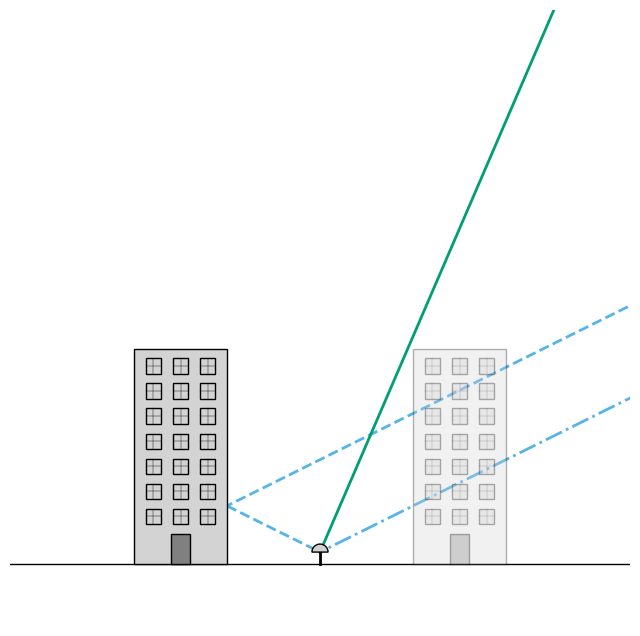

In [36]:
ground = Ground()

receiver = Receiver(position=(0,2), antenna_height=2)

building = Building(position=(-30,0), height=35, width=15)
image_building = Building(position=(15,0), height=35, width=15)#, plot_windows=False, plot_door=False)

far_satellite_1 = Satellite(position=(10e9, 5e9))
far_satellite_2 = Satellite(position=(6e9, 14e9))

fixed_x_limits = (-50, 50)

fig, ax = plt.subplots(figsize=(8,8))

ground.plot(ax)

receiver.plot(ax)
building.plot(ax)
image_building.plot(ax, alpha=0.3)

far_satellite_1.draw_signal(ax, building, receiver, color='#56B4E9', linewidth=2, linestyle='--')
far_satellite_1.draw_signal(ax, receiver, color='#56B4E9', linewidth=2, linestyle='-.')
far_satellite_2.draw_signal(ax, building, receiver, color='#009E73', linewidth=2, linestyle='--')
far_satellite_2.draw_signal(ax, receiver, color='#009E73', linewidth=2, linestyle='-')

# static settings
ax.set_xlim(fixed_x_limits)
ax.set_ylim([-10, fixed_x_limits[1]-fixed_x_limits[0]-10])

ax.axis('off')
plt.tick_params(left = False, right = False, labelleft = False, labelbottom = False, bottom = False) 

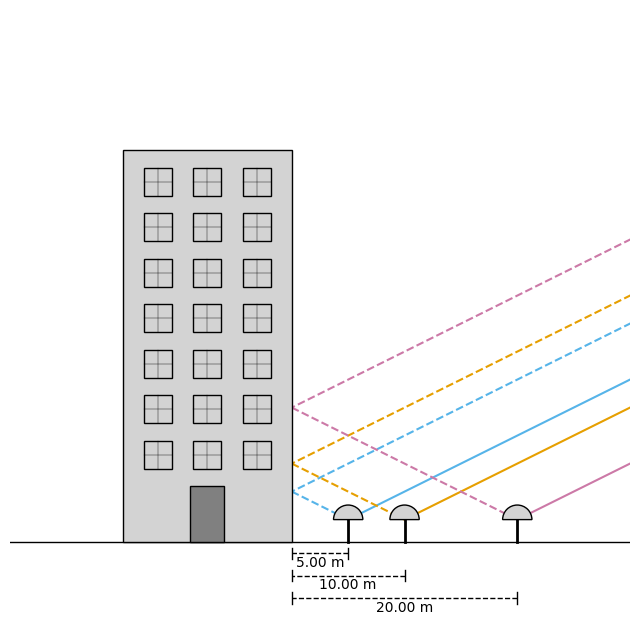

In [45]:
ground = Ground()
receiver_5m = Receiver(position=(5,2), antenna_height=2)
receiver_10m = Receiver(position=(10,2), antenna_height=2)
receiver_20m = Receiver(position=(20,2), antenna_height=2)

building = Building(position=(-15,0), height=35, width=15)

far_satellite = Satellite(position=(10e9, 5e9))

fixed_x_limits = (-25, 30)

fig, ax = plt.subplots(figsize=(8,8))
ground.plot(ax)

building.plot(ax)

far_satellite.plot(ax)

receiver_5m.plot(ax)
receiver_10m.plot(ax)
receiver_20m.plot(ax)

receiver_5m.draw_distance(ax, building, adjusted_y=1, text_offset=1.5)
receiver_10m.draw_distance(ax, building, adjusted_y=3, text_offset=1.5)
receiver_20m.draw_distance(ax, building, adjusted_y=5, text_offset=1.5)

far_satellite.draw_signal(ax, building, receiver_5m, color='#56B4E9', linewidth=1.5, linestyle='--')
far_satellite.draw_signal(ax, receiver_5m, color='#56B4E9', linewidth=1.5, linestyle='-')
far_satellite.draw_signal(ax, building, receiver_10m, color='#E69F00', linewidth=1.5, linestyle='--')
far_satellite.draw_signal(ax, receiver_10m, color='#E69F00', linewidth=1.5, linestyle='-')
far_satellite.draw_signal(ax, building, receiver_20m, color='#CC79A7', linewidth=1.5, linestyle='--')
far_satellite.draw_signal(ax, receiver_20m, color='#CC79A7', linewidth=1.5, linestyle='-')

# static settings
ax.set_xlim(fixed_x_limits)
ax.set_ylim([-7.5, fixed_x_limits[1]-fixed_x_limits[0]-7.5])

ax.axis('off')
plt.tick_params(left = False, right = False, labelleft = False, labelbottom = False, bottom = False) 

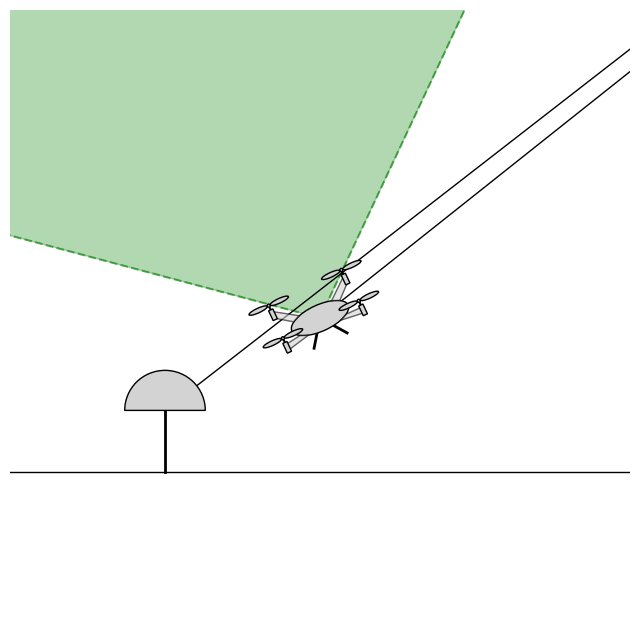

In [ ]:
drone = Drone(position=(-5, 5), rotation=25)
ground =  Ground(groundtype='Common')
building = Building(position=(10,0), height=25, width=20)
receiver_left = Receiver(position=(-10,2), antenna_height=2, antennatype='Geodetic')

close_satellite_1 = Satellite(position=(-25,45), rotation=25)

fixed_x_limits = (-15, 5)

fig, ax = plt.subplots(figsize=(8,8))
ground.plot(ax)

# drone.plot(ax, number_of_arms=6, arm_position_offset=0, arm_tilt_angle=0, leg_angles=12, rotor_angle=0)
drone.plot(ax, number_of_arms=4, arm_position_offset=45, leg_angles=18, leg_length=1, scale=1)
building.plot(ax)
receiver_left.plot(ax, tilt_angle=45)

# receiver.draw_radiation(ax, field_of_view=75, length=250)
drone.draw_radiation(ax, field_of_view=50, length=250)

close_satellite_1.plot(ax, scale=1)
close_satellite_1.draw_signal(ax, building, drone)
close_satellite_1.draw_signal(ax, building, receiver_left)

# static settings

ax.set_xlim(fixed_x_limits)
ax.set_ylim([-5, fixed_x_limits[1]-fixed_x_limits[0]-5])

ax.axis('off')
plt.tick_params(left = False, right = False, labelleft = False, labelbottom = False, bottom = False) 

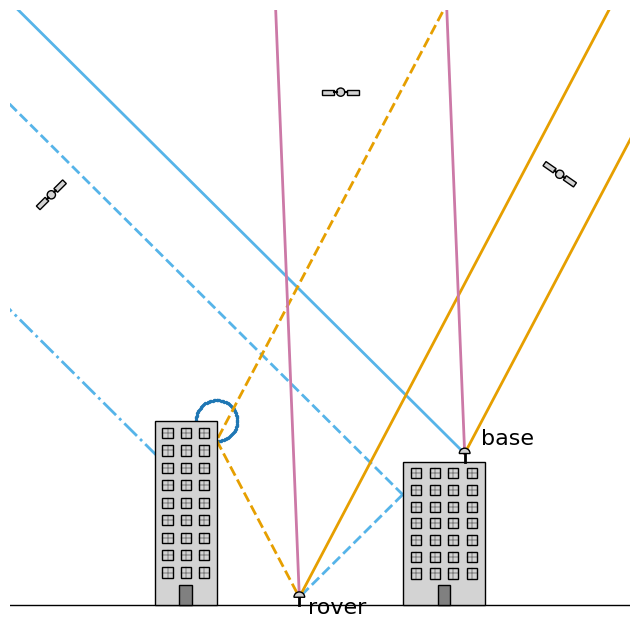

In [4]:
rover = Receiver(position=(-5, 2), antenna_height=2, antennatype='Geodetic')
ground =  Ground(groundtype='Common')
building_right = Building(position=(20,0), height=35, width=20)
building_left = Building(position=(-40,0), height=45, width=15)
base = Receiver(position=(building_right.position[0]+15, building_right.height+2), antenna_height=2, antennatype='Geodetic')

close_satellite_1 = Satellite(position=(-65,100), rotation=45)
transmitting_satellite_1 = Satellite(position=(-25*2e8, 25*2e8))
close_satellite_2 = Satellite(position=(58,105), rotation=-35)
transmitting_satellite_2 = Satellite(position=(55*2e8, 105*2e8))
close_satellite_3 = Satellite(position=(5,125), rotation=0)
transmitting_satellite_3 = Satellite(position=(-5*2e8, 125*2e8))

fixed_x_limits = (-75, 75)

fig, ax = plt.subplots(figsize=(8,8))
ground.plot(ax)

# drone.plot(ax, number_of_arms=6, arm_position_offset=0, arm_tilt_angle=0, leg_angles=12, rotor_angle=0)
rover.plot(ax, text_string=f'rover', text_offset=(2,-4), text_size=16)#, scale=1.75)
building_right.plot(ax)
building_left.plot(ax)
base.plot(ax, text_string=f'base', text_offset=(4, 2), text_size=16)

close_satellite_1.plot(ax, scale=1)
close_satellite_2.plot(ax, scale=1)
close_satellite_3.plot(ax, scale=1)

transmitting_satellite_1.draw_signal(ax, building_right, rover, color='#56B4E9', linestyle='--', linewidth=2)
transmitting_satellite_1.draw_signal(ax, rover, building_left, color='#56B4E9', linestyle='-.', linewidth=2)
transmitting_satellite_1.draw_signal(ax, base, color='#56B4E9', linewidth=2)

transmitting_satellite_2.draw_signal(ax, building_right, rover, color='#E69F00', linewidth=2)
transmitting_satellite_2.draw_signal(ax, building_left, rover, color='#E69F00', linestyle='--', linewidth=2)
transmitting_satellite_2.draw_signal(ax, rover, color='#E69F00', linewidth=2)
transmitting_satellite_2.draw_signal(ax, base, color='#E69F00', linewidth=2)

transmitting_satellite_3.draw_signal(ax, building_right, rover, color='#CC79A7', linewidth=2)
transmitting_satellite_3.draw_signal(ax, building_left, rover, color='#CC79A7', linewidth=2)
transmitting_satellite_3.draw_signal(ax, rover, color='#CC79A7', linewidth=2)
transmitting_satellite_3.draw_signal(ax, base, color='#CC79A7', linewidth=2)

# static settings

ax.set_xlim(fixed_x_limits)
ax.set_ylim([-5, fixed_x_limits[1]-fixed_x_limits[0]-5])

ax.axis('off')
plt.tick_params(left = False, right = False, labelleft = False, labelbottom = False, bottom = False) 

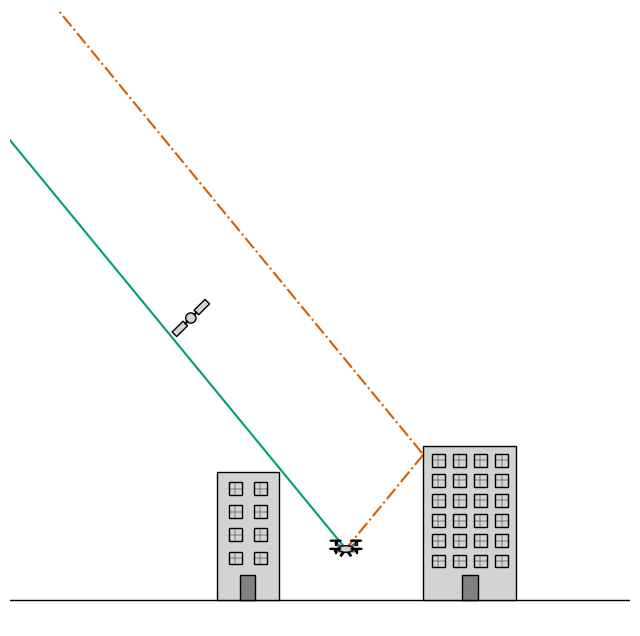

In [ ]:
time = np.arange(0, 8*60, step=1, dtype=np.int32)

# index = 100 # no direct signal and no reflection on left building
# index = 150 # left building gets a reflection but no direct signal
index = 325 # right building gets a reflection but no direct signal
# index = 365 # no direct signal and no reflection on right building

fig, ax = plt.subplots(figsize=(8, 8))
fixed_x_limits = (-60, 60)
fixed_y_limits = [-5, fixed_x_limits[1] - fixed_x_limits[0] - 5]

ground = Ground(height=0, groundtype='Common')
drone = Drone(position=(5, ground.height + 10),)
building_right = Building(position=(20, ground.height),height=30,width=18,)
building_left = Building(position=(-20, ground.height),height=25,width=12,)
close_satellite_1 = Satellite(position=(-25, 55), rotation=45)

# Initial satellite position (will be overwritten)
transmitting_satellite_1 = Satellite(position=(-45, 55), rotation=90)
# Ellipse parameters (meters)
ellipse_center = drone.position   
a = 21000e3                            # semi-major axis
b_transmitting = 16000e3                            # semi-minor axis
# Angular motion
omega = np.pi / (8 * 60)        # one full ellipse in 8 minutes

# --- Elliptical motion ---
ax.clear()
theta = omega * time[index]

x_transmitting_sat = ellipse_center[0] + a * np.cos(theta)
y_transmitting_sat = ellipse_center[1] + b_transmitting * np.sin(theta)

transmitting_satellite_1.position = (x_transmitting_sat, y_transmitting_sat)

# Optional: rotate satellite to face receiver
dx = drone.position[0] - x_transmitting_sat
dy = drone.position[1] - y_transmitting_sat
transmitting_satellite_1.rotation = np.degrees(np.arctan2(dy, dx))

# --- Draw static objects ---
ground.plot(ax)
drone.plot(ax, number_of_arms=4, arm_position_offset=45, leg_angles=18, leg_length=1, scale=1.5)
building_right.plot(ax)
building_left.plot(ax)
close_satellite_1.plot(ax)

# --- Draw signals ---
if time[index] < len(time)//2:
    transmitting_satellite_1.draw_signal(ax, drone, building_right,color='#009E73', linewidth=1.5)
else:
    transmitting_satellite_1.draw_signal(ax, drone, building_left,color='#009E73', linewidth=1.5)

transmitting_satellite_1.draw_signal(ax, building_left, building_right, drone, color='#D55E00', linestyle='-.', linewidth=1.5)
# transmitting_satellite.draw_signal(ax, building_left, receiver, color='#D55E00', linestyle='-.', linewidth=1.5)
# transmitting_satellite.draw_signal(ax, building_right, receiver, color='#D55E00', linestyle='-.', linewidth=1.5)

# --- Static view window ---
ax.set_xlim(fixed_x_limits)
ax.set_ylim([-5, fixed_x_limits[1] - fixed_x_limits[0] - 5])
ax.axis('off')

plt.show()


TypeError: 'Drone' object is not subscriptable

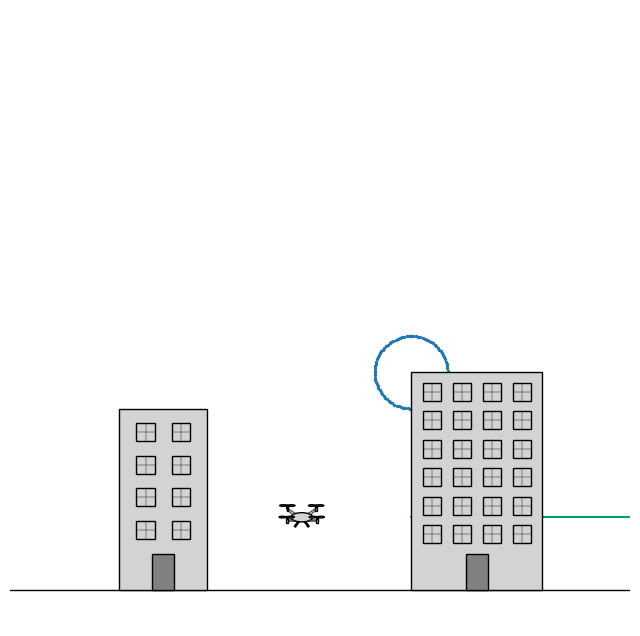

In [6]:
from matplotlib.animation import FuncAnimation, PillowWriter

time = np.arange(0, 8*60, step=1, dtype=np.int32)

fig, ax = plt.subplots(figsize=(8, 8))

fixed_x_limits = (-35, 50)
fixed_y_limits = [-5, fixed_x_limits[1] - fixed_x_limits[0] - 5]

ground = Ground(height=0)

drone = Drone(
    position=(5, ground.height + 10),
)

building_right = Building(
    position=(20, ground.height),
    height=30,
    width=18,
    reflection='Specular'
)

building_left = Building(
    position=(-20, ground.height),
    height=25,
    width=12,
    reflection='Specular'
)

close_satellite_1 = Satellite(position=(-25, 55), rotation=45)

# Initial satellite position (will be overwritten)
transmitting_satellite_1 = Satellite(position=(-45, 55), rotation=90)

drone_initial_position = drone.position

def update(frame):
    ax.clear()

    t = time[frame]

    # Ellipse parameters (meters)
    ellipse_center = drone_initial_position 
    a_transmitting = 21000e3                            # semi-major axis
    b_transmitting = 16000e3                            # semi-minor axis
    a_close = a_transmitting/300e3
    b_close = b_transmitting/250e3

    # Angular motion
    omega = np.pi / (8 * 60)        # one full ellipse in 8 minutes

    # --- Elliptical motion ---
    theta = omega * t

    x_transmitting_sat = ellipse_center[0] + a_transmitting * np.cos(theta)
    y_transmitting_sat = ellipse_center[1] + b_transmitting * np.sin(theta)
    x_close_sat = ellipse_center[0] + a_close * np.cos(theta)
    y_close_sat = ellipse_center[1] + b_close * np.sin(theta)

    transmitting_satellite_1.position = (x_transmitting_sat, y_transmitting_sat)
    close_satellite_1.position = (x_close_sat, y_close_sat)

    # Rotate satellite to face receiver
    dx = drone.position[0] - x_transmitting_sat
    dy = drone.position[1] - y_transmitting_sat
    close_satellite_1.rotation = np.degrees(np.arctan2(dy, dx)) + 90

    # Drone movement
    a = 1.0
    omega = 2*np.pi / 20
    theta_max = 5.0        # degrees
    omega_rot = 2*np.pi / 6  # one full sway every 6 seconds    

    x = drone_initial_position[0]# + a * np.sin(omega * t)
    y = drone_initial_position[1] + a * np.cos(omega * t + np.pi/2)

    drone.position = (x,y)

    drone.rotation = theta_max * np.sin(omega_rot * t)

    # --- Draw static objects ---
    ground.plot(ax)
    drone.plot(ax, number_of_arms=4, arm_position_offset=45, leg_angles=18, leg_length=1, scale=1.5)
    building_right.plot(ax)
    building_left.plot(ax)
    close_satellite_1.plot(ax)

    # --- Draw signals ---
    if t < len(time)//2:
        transmitting_satellite_1.draw_signal(
            ax, drone, building_right,
            color='#009E73', linewidth=1.5
        )
    else:
        transmitting_satellite_1.draw_signal(
            ax, drone, building_left,
            color='#009E73', linewidth=1.5
        )
    transmitting_satellite_1.draw_signal(ax, building_left, building_right, drone, color='#D55E00', linestyle='-.', linewidth=1.5)
    # --- Static view window ---
    ax.set_xlim(fixed_x_limits)
    ax.set_ylim([-5, fixed_x_limits[1] - fixed_x_limits[0] - 5])
    ax.axis('off')

anim = FuncAnimation(
    fig,
    update,
    frames=len(time),
    interval=50  # ms between frames
)

writer = PillowWriter(fps=20)
anim.save(f"note_figures/multipath_animation_drone.gif", writer=writer)


In [ ]:
print(drone.position)
print(transmitting_satellite_1.position)

np.linalg.norm(np.array([*drone.position])-np.array([*transmitting_satellite_1.position]))/1e3

(5, np.float64(10.0))
(np.float64(21000005.0), np.float64(10.0))


np.float64(21000.0)

Intersection height: 10.0
Wall limits: 0.0 30.0


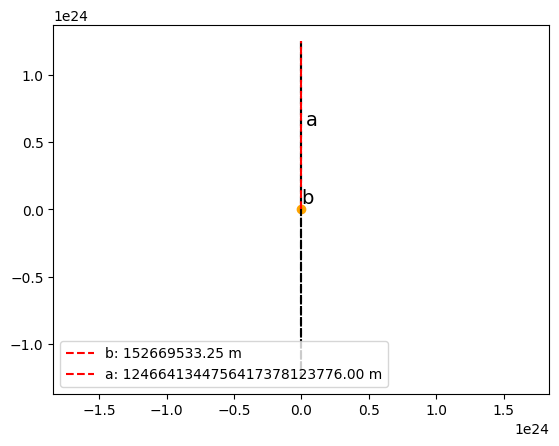

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def angle_2D(L1_x, L1_y, L2_x, L2_y):
    "calculate the angle between two lines"
    L1_vector = np.array([L1_x[1] - L1_x[0], L1_y[1] - L1_y[0]])
    L2_vector = np.array([L2_x[1] - L2_x[0], L2_y[1] - L2_y[0]])

    dot_product = np.dot(L1_vector, L2_vector)

    L1_magnitude, L2_magnitude = np.linalg.norm(L1_vector), np.linalg.norm(L2_vector)

    cos_angle = dot_product/ (L1_magnitude*L2_magnitude)
    return np.arccos(cos_angle)

R = 6371e03 # m
theta = np.linspace(0,2*np.pi,1000)

r = np.array([drone.position[0],drone.position[1]+R]) # pos in m
s = np.array([transmitting_satellite_1.position[0]+R,transmitting_satellite_1.position[1]+R]) # pos in m

# define wall with points 
N = 100
x_wall = building_right.position[0]
y_wall_min = ground.height + R
y_wall_max = building_right.height + R

# define position of image receiver
if y_wall_min <= r[1] <= y_wall_max:
    # perpendicular projection hits the wall
    r_dist = abs(r[0] - x_wall)
    wall_closest_r = np.array([x_wall, r[1]])
else:
    # closest point is one of the wall endpoints
    d_bottom = np.hypot(r[0] - x_wall, r[1] - y_wall_min)
    d_top    = np.hypot(r[0] - x_wall, r[1] - y_wall_max)

    if d_bottom < d_top:
        r_dist = d_bottom
        wall_closest_r = np.array([x_wall, y_wall_min])
    else:
        r_dist = d_top
        wall_closest_r = np.array([x_wall, y_wall_max])
        
img_r = r+2*(wall_closest_r-r)

img_r = np.array([2*x_wall - r[0],r[1]])


# define lines for wall and direct signal between satellite and image receiver
L1_x = np.array([x_wall,x_wall])
L2_x = np.array([img_r[0],s[0]])
L1_y = np.array([y_wall_min,y_wall_max])
L2_y = np.array([img_r[1],s[1]])

# ray direction
# d = img_r - s
d = s - img_r

# solve x(t) = x_wall
t = (x_wall - s[0]) / d[0]

# intersection point
x_intersect = s[0] + t * d[0]
y_intersect = s[1] + t * d[1]

print("Intersection height:", y_intersect - R)
print("Wall limits:", y_wall_min - R, y_wall_max - R)

# reflection point
p = np.array([x_intersect, y_intersect])

# incoming ray vector (satellite -> reflection point)
v_in = s - p

# wall normal (vertical wall)
n_wall = np.array([1.0, 0.0])   # or [-1.0, 0.0]

# incidence angle
angle_rad = np.arccos(
    np.dot(v_in, n_wall) /
    (np.linalg.norm(v_in) * np.linalg.norm(n_wall))
)

## define the first Fresnel zone
# calculate the wavelength
c = 299792458 # m/s
freq_L1 = 1575.42e06 # in Hz
lambda_L1 = c/freq_L1 # in m

# find length between receiver and reflector
d = np.linalg.norm(r - wall_closest_r)

# calculate semimajor and semiminor axis depending on incidence angle for first Fresnel zone
b = np.sqrt((lambda_L1 * d)/(np.sin(np.pi-angle_rad)) + ((lambda_L1)/2*np.sin(np.pi-angle_rad))**2)
a = b / np.sin(np.pi-angle_rad)

phi = np.linspace(0, 2*np.pi,100)

x = x_intersect + b * np.sin(phi)
y = y_intersect + a * np.cos(phi)

plt.figure()
plt.plot(x,y-R,'k--')
plt.scatter(x_intersect,y_intersect-R,color='orange')
plt.plot([x_intersect, x_intersect+b],[y_intersect-R, y_intersect-R], 'r--',label=f'b: {b:.2f} m')
plt.plot([x_intersect, x_intersect],[y_intersect-R, y_intersect+a-R], 'r--',label=f'a: {a:.2f} m')
plt.plot([x_wall-building_right.width/2, x_wall+building_right.width/2], [y_wall_min-R, y_wall_min-R], color='lightgray')
plt.plot([x_wall+building_right.width/2, x_wall+building_right.width/2], [y_wall_min-R, y_wall_max-R], color='lightgray')
plt.plot([x_wall-building_right.width/2, x_wall+building_right.width/2], [y_wall_max-R, y_wall_max-R], color='lightgray')
plt.plot([x_wall-building_right.width/2, x_wall-building_right.width/2], [y_wall_max-R, y_wall_min-R], color='lightgray')
plt.annotate('b',xy=(x_intersect + b/2,y_intersect-R),
                 xytext=(0, 4), textcoords='offset points', fontsize=14)
plt.annotate('a',xy=(x_intersect,y_intersect-R + a/2),
                 xytext=(3, 0), textcoords='offset points', fontsize=14)
plt.axis('equal')
plt.legend()
# plt.axis('off')
plt.show()


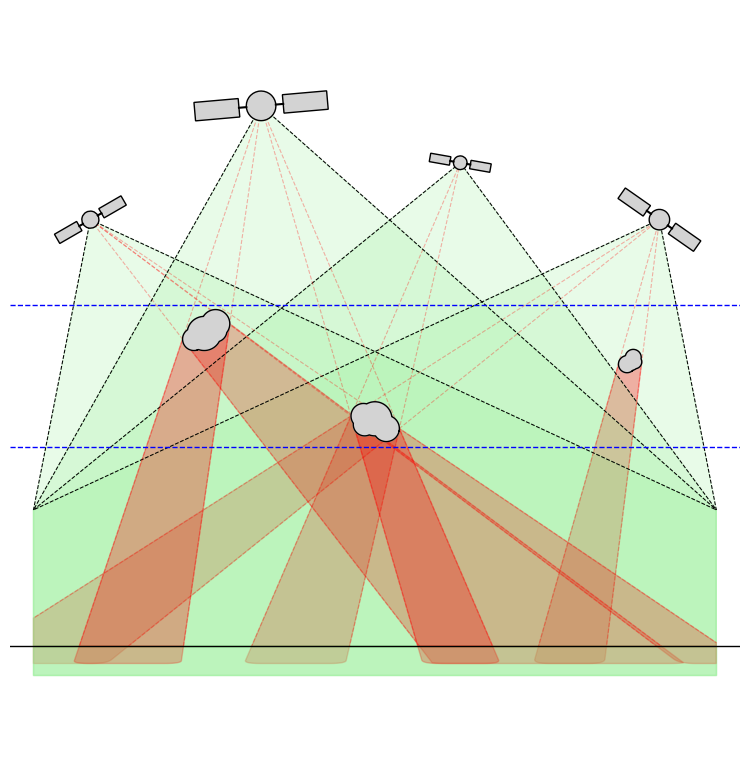

In [ ]:
first_satellite = Satellite(position=(-35, 75), rotation=30)
second_satellite = Satellite(position=(-5, 95), rotation=5)
third_satellite = Satellite(position=(30, 85), rotation=-10)
fourth_satellite = Satellite(position=(65, 75), rotation=-35)

cloud_right = Blob(position=(60, 50), radius=1.5,
                  offsets_blobs=[(0.7, 0), (0.4, 0.8), (-0.7, -0.4)], radii_blobs=[1.2, 1.4, 1.5])
cloud_left = Blob(position=(-15, 55), radius=3,
                  offsets_blobs=[(2, 0.5), (2, 1.7), (-1.8, -1)], radii_blobs=[2, 2.5, 2])
cloud_middle = Blob(position=(15, 40), radius=3,
                  offsets_blobs=[(-2, 0.5), (2, -1.7), (-1.8, -1)], radii_blobs=[2.2, 2.3, 2])


ground = Ground()
ionospheric_layer = Ground(height=60)
tropospheric_layer = Ground(height=35)


fixed_x_limits = (-45, 75)
fill_color = 'lightgreen'
fill_alpha = 0.2


fig, ax = plt.subplots(figsize=(8,8))

ground.plot(ax)
ionospheric_layer.plot(ax,color='blue', linestyle='--')
tropospheric_layer.plot(ax,color='blue', linestyle='--')

first_satellite.plot(ax, scale=1.5)
second_satellite.plot(ax, scale=2.6)
third_satellite.plot(ax, scale=1.2)
fourth_satellite.plot(ax, scale=1.8)

fourth_satellite.draw_footprint(ax, ground, cloud_right, cloud_middle, cloud_left,
                                edge_linewidth=0.75, 
                                x_limits=fixed_x_limits, fill_color=fill_color, fill_alpha=fill_alpha)
third_satellite.draw_footprint(ax, ground, cloud_right, cloud_middle, cloud_left,
                               edge_linewidth=0.75, 
                               x_limits=fixed_x_limits, fill_color=fill_color, fill_alpha=fill_alpha)
first_satellite.draw_footprint(ax, ground, cloud_right, cloud_middle, cloud_left,
                               edge_linewidth=0.75, 
                               x_limits=fixed_x_limits, fill_color=fill_color, fill_alpha=fill_alpha)
second_satellite.draw_footprint(ax, ground, cloud_right, cloud_middle, cloud_left,
                                edge_linewidth=0.75, 
                                x_limits=fixed_x_limits, fill_color=fill_color, fill_alpha=fill_alpha)

cloud_right.plot(ax)
cloud_left.plot(ax)
cloud_middle.plot(ax)

# static settings

ax.set_xlim(fixed_x_limits)

plt.axis('equal')
plt.tight_layout()
ax.axis('off')
plt.tick_params(left = False, right = False, labelleft = False, labelbottom = False, bottom = False) 
plt.savefig(f'note_figures/scintillation_blobs.png')
plt.show()

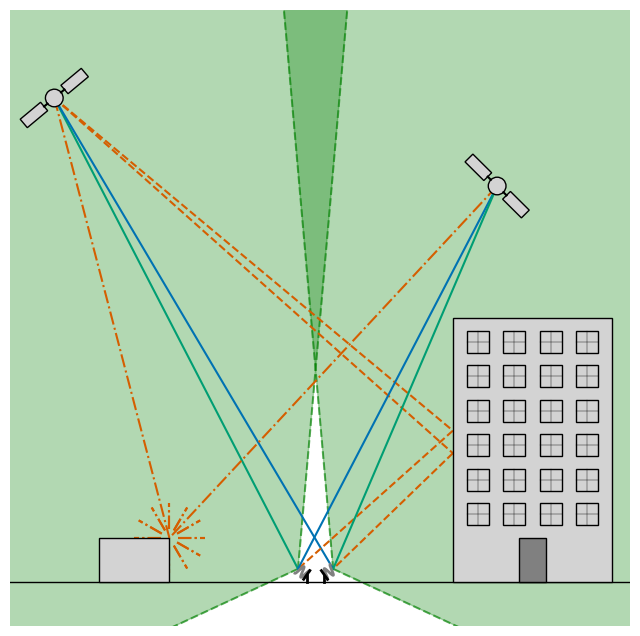

In [ ]:
ground = Ground(height=0, groundtype='Common')
receiver_left = Receiver(position=(3.5,ground.height+2),antenna_height=2, antennatype='Helix')
receiver_right = Receiver(position=(5.5,ground.height+2),antenna_height=2, antennatype='Helix')

left_close_satellite = Satellite(position=(-25,55), rotation=40)
right_close_satellite = Satellite(position=(25, 45), rotation=-45)

building_right = Building(position=(20,ground.height), height=30, width=18, reflection='Specular')
building_left = Building(position=(-20,ground.height), height=5, width=8, plot_door=False, plot_windows=False, reflection='Diffuse')

fixed_x_limits = (-30, 40)

fig, ax = plt.subplots(figsize=(8,8))

ground.plot(ax)

receiver_left.plot(ax, radius=0.6, helix_height=1.2, n_turns=1.5, tilt_angle=55)
receiver_left.draw_radiation(ax, field_of_view=60, length=250)

receiver_right.plot(ax, radius=0.6, helix_height=1.2, n_turns=1.5, tilt_angle=-55)
receiver_right.draw_radiation(ax, field_of_view=60, length=250)

building_right.plot(ax,)
building_left.plot(ax)

left_close_satellite.plot(ax)
left_close_satellite.draw_signal(ax, receiver_left, color='#009E73', linewidth=1.5)
left_close_satellite.draw_signal(ax, receiver_right, color='#0072B2', linewidth=1.5)
left_close_satellite.draw_signal(ax, building_right, receiver_left, color='#D55E00', linestyle='--', linewidth=1.5)
left_close_satellite.draw_signal(ax, building_right, receiver_right, color='#D55E00', linestyle='--', linewidth=1.5)
left_close_satellite.draw_signal(ax, building_left, receiver_left, color='#D55E00', linestyle='-.', linewidth=1.5)

right_close_satellite.plot(ax)
right_close_satellite.draw_signal(ax, receiver_left, color='#0072B2', linewidth=1.5)
right_close_satellite.draw_signal(ax, receiver_right, color='#009E73', linewidth=1.5)
right_close_satellite.draw_signal(ax, building_left, receiver_right, color='#D55E00', linestyle='-.', linewidth=1.5)

# static settings

# ax.set_aspect('equal', adjustable='datalim')
ax.set_xlim(fixed_x_limits)
ax.set_ylim([-5, fixed_x_limits[1]-fixed_x_limits[0]-5])
# plt.tight_layout()

ax.axis('off')
plt.tick_params(left = False, right = False, labelleft = False, labelbottom = False, bottom = False) 
plt.savefig(f'note_figures/tilted_helical_antennas.png')

plt.show()

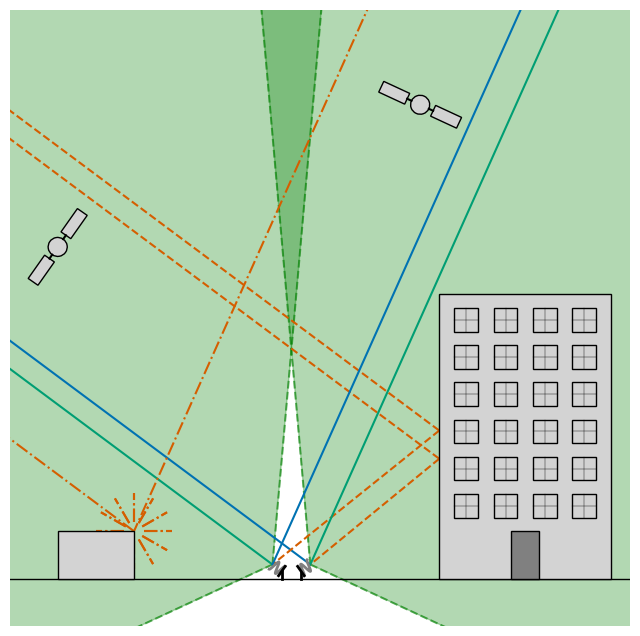

In [ ]:
ground = Ground(height=0, groundtype='Common')
receiver_left = Receiver(position=(3.5,ground.height+2),antenna_height=2, antennatype='Helix')
receiver_right = Receiver(position=(5.5,ground.height+2),antenna_height=2, antennatype='Helix')

left_close_satellite = Satellite(position=(-20, 35), rotation=55)
right_close_satellite = Satellite(position=(18, 50), rotation=-25)

left_far_satellite = Satellite(position=(-20e6, 15e6), rotation=40)
right_far_satellite = Satellite(position=(20e8, 45e8), rotation=-45)

building_right = Building(position=(20,ground.height), height=30, width=18, reflection='Specular')
building_left = Building(position=(-20,ground.height), height=5, width=8, plot_door=False, plot_windows=False, reflection='Diffuse')


fixed_x_limits = (-25, 40)

fig, ax = plt.subplots(figsize=(8,8))

ground.plot(ax)

receiver_left.plot(ax, radius=0.6, helix_height=1.2, n_turns=1.5, tilt_angle=55)
receiver_left.draw_radiation(ax, field_of_view=60, length=250)

receiver_right.plot(ax, radius=0.6, helix_height=1.2, n_turns=1.5, tilt_angle=-55)
receiver_right.draw_radiation(ax, field_of_view=60, length=250)

building_right.plot(ax,)
building_left.plot(ax)

left_close_satellite.plot(ax)
left_far_satellite.draw_signal(ax, receiver_left, color='#009E73', linewidth=1.5)
left_far_satellite.draw_signal(ax, receiver_right, color='#0072B2', linewidth=1.5)
left_far_satellite.draw_signal(ax, building_right, receiver_left, color='#D55E00', linestyle='--', linewidth=1.5, test_color='orange')
left_far_satellite.draw_signal(ax, building_right, receiver_right, color='#D55E00', linestyle='--', linewidth=1.5, test_color='purple')
left_far_satellite.draw_signal(ax, building_left, receiver_left, color='#D55E00', linestyle='-.', linewidth=1.5)

right_close_satellite.plot(ax)
right_far_satellite.draw_signal(ax, receiver_left, color='#0072B2', linewidth=1.5)
right_far_satellite.draw_signal(ax, receiver_right, color='#009E73', linewidth=1.5)
right_far_satellite.draw_signal(ax, building_left, receiver_right, color='#D55E00', linestyle='-.', linewidth=1.5)

# static settings

# ax.set_aspect('equal', adjustable='datalim')
ax.set_xlim(fixed_x_limits)
ax.set_ylim([-5, fixed_x_limits[1]-fixed_x_limits[0]-5])
# plt.tight_layout()

ax.axis('off')
plt.tick_params(left = False, right = False, labelleft = False, labelbottom = False, bottom = False) 
plt.savefig(f'note_figures/tilted_helical_antennas_realistic_angles.png')

plt.show()

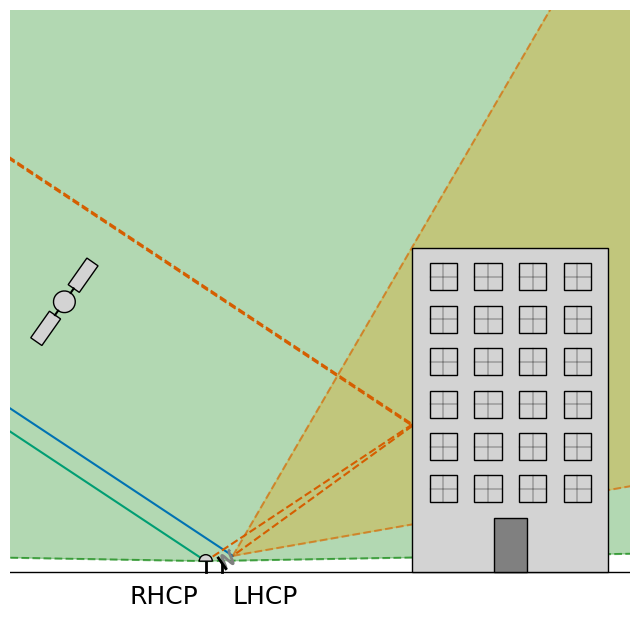

In [ ]:
ground = Ground(height=0, groundtype='Common')
receiver_left = Receiver(position=(1,ground.height+1),antenna_height=1, antennatype='Geodetic')
receiver_right = Receiver(position=(2.5,ground.height+2),antenna_height=2, antennatype='Helix')

left_close_satellite = Satellite(position=(-12, 25), rotation=55)

left_far_satellite = Satellite(position=(-60e8, 40e8), rotation=40)

building_right = Building(position=(20,ground.height), height=30, width=18, reflection='Specular')
fixed_x_limits = (-17, 40)

fig, ax = plt.subplots(figsize=(8,8))

ground.plot(ax)

receiver_left.plot(ax, radius=0.6, helix_height=1.2, n_turns=1.5, tilt_angle=0, text_string=f'RHCP', text_offset=(-7,-4), text_size=18)
receiver_left.draw_radiation(ax, field_of_view=89, length=4000)

receiver_right.plot(ax, radius=0.6, helix_height=1.2, n_turns=1.5, tilt_angle=-55, text_string=f'LHCP', text_offset=(1,-5), text_size=18)
receiver_right.draw_radiation(ax, field_of_view=25, length=250, fill_color='#E69F00', linecolor='#D55E00')

building_right.plot(ax,)

left_close_satellite.plot(ax)
left_far_satellite.draw_signal(ax, receiver_left, color='#009E73', linewidth=1.5)
left_far_satellite.draw_signal(ax, receiver_right, color='#0072B2', linewidth=1.5)
left_far_satellite.draw_signal(ax, building_right, receiver_left, color='#D55E00', linestyle='--', linewidth=1.5)
left_far_satellite.draw_signal(ax, building_right, receiver_right, color='#D55E00', linestyle='--', linewidth=1.5)

# static settings

ax.set_xlim(fixed_x_limits)
ax.set_ylim([-5, fixed_x_limits[1]-fixed_x_limits[0]-5])

ax.axis('off')
plt.tick_params(left = False, right = False, labelleft = False, labelbottom = False, bottom = False) 
plt.savefig(f'note_figures/tilted_LHCP_helical_antenna_realistic_angles.png') 

plt.show()

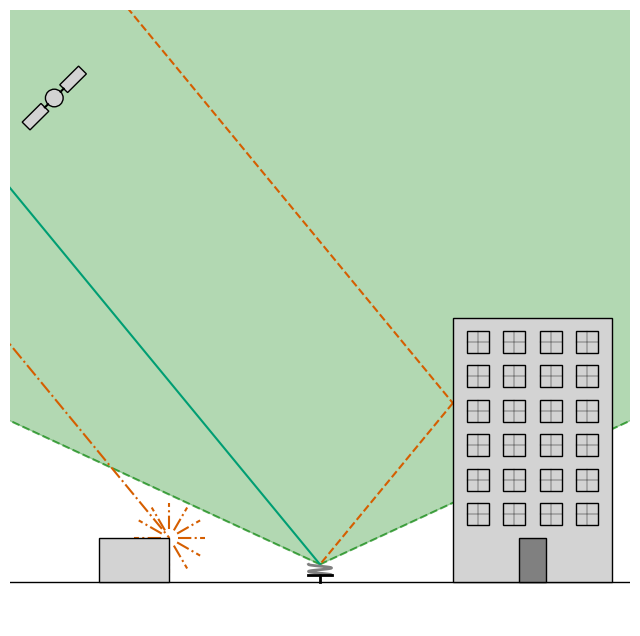

In [ ]:
ground = Ground(height=0, groundtype='Common')

drone = Receiver(position=(5,ground.height+2),antenna_height=2, antennatype='Helix')

building_right = Building(position=(20,ground.height), height=30, width=18, reflection='Specular')

building_left = Building(position=(-20,ground.height), height=5, width=8, plot_door=False, plot_windows=False, reflection='Diffuse')

close_satellite_1 = Satellite(position=(-25,55), rotation=45)
transmitting_satellite_1 = Satellite(position=(-45e8, 55e8), rotation=90)

fixed_x_limits = (-30, 40)

fig, ax = plt.subplots(figsize=(8,8))

# components for figure
drone.plot(ax)
# receiver.draw_distance(ax,building_right, text_offset=2.5) #, distance_string=f'10 m')
drone.draw_radiation(ax, field_of_view=65, length=200)

ground.plot(ax)

building_right.plot(ax,)

building_left.plot(ax)

close_satellite_1.plot(ax)
transmitting_satellite_1.draw_signal(ax, drone, color='#009E73', linewidth=1.5)
transmitting_satellite_1.draw_signal(ax, building_right, drone, color='#D55E00', linestyle='--', linewidth=1.5)
transmitting_satellite_1.draw_signal(ax, building_left, drone, color='#D55E00', linestyle='-.', linewidth=1.5)


# static settings

ax.set_xlim(fixed_x_limits)
ax.set_ylim([-5, fixed_x_limits[1]-fixed_x_limits[0]-5])

ax.axis('off')
plt.tick_params(left = False, right = False, labelleft = False, labelbottom = False, bottom = False) 
plt.savefig(f'note_figures/multipath_reflections_helical_realistic_angles.png')
plt.show()

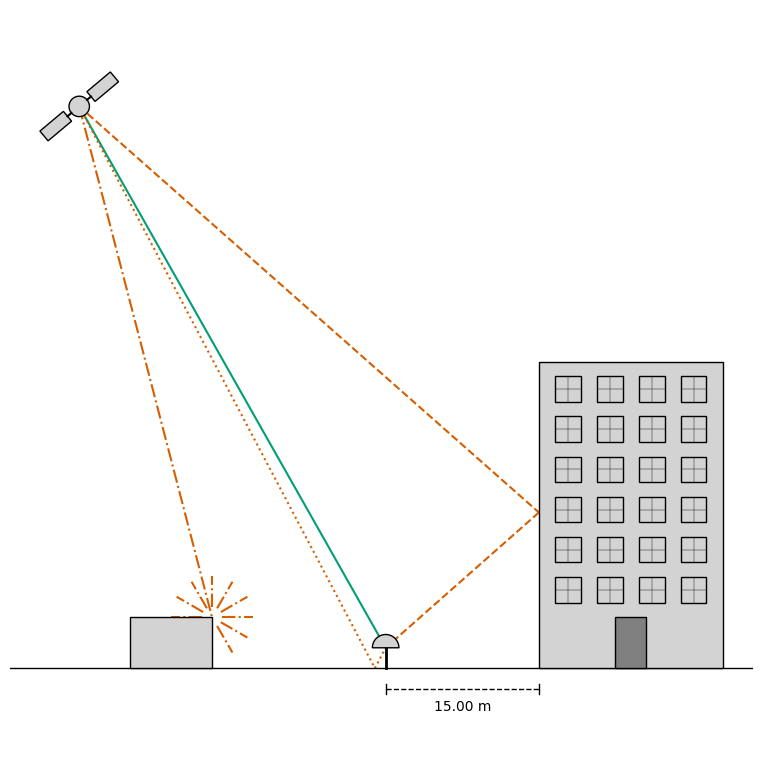

In [ ]:
ground = Ground(height=0, groundtype='Common')

drone = Receiver(position=(5,ground.height+2),antenna_height=2)

building_right = Building(position=(20,ground.height), height=30, width=18, reflection='Specular')

building_left = Building(position=(-20,ground.height), height=5, width=8, plot_door=False, plot_windows=False, reflection='Diffuse')

satellite = Satellite(position=(-25,55), rotation=40)

fig, ax = plt.subplots(figsize=(8,8))

# components for figure
drone.plot(ax)
drone.draw_distance(ax,building_right, text_offset=2.5) #, distance_string=f'10 m')

ground.plot(ax)

building_right.plot(ax,)

building_left.plot(ax)

satellite.plot(ax)
satellite.draw_signal(ax, drone, color='#009E73', linewidth=1.5)
satellite.draw_signal(ax, building_right, drone, color='#D55E00', linestyle='--', linewidth=1.5)
satellite.draw_signal(ax, building_left, drone, color='#D55E00', linestyle='-.', linewidth=1.5)
satellite.draw_signal(ax, ground, drone, color='#D55E00', linestyle=':', linewidth=1.5)


# static settings

plt.axis('equal')
plt.tight_layout()
ax.axis('off')
plt.tick_params(left = False, right = False, labelleft = False, labelbottom = False, bottom = False) 
plt.savefig(f'note_figures/multipath_reflections_type.png')
plt.show()

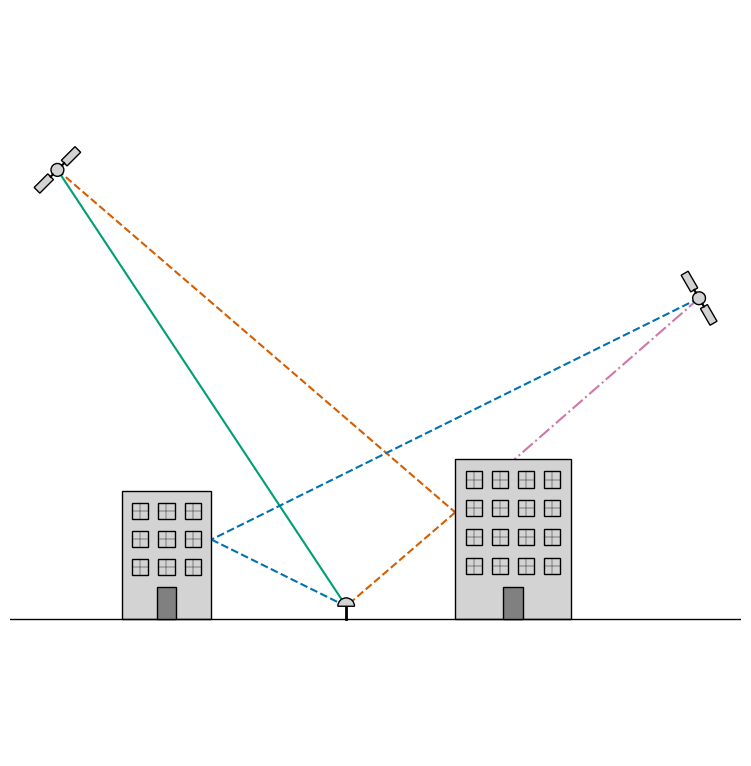

In [ ]:
drone = Receiver(position=(5,2),antenna_height=2)

building_left = Building(position=(-30,0), height=20, width=14)
building_right = Building(position=(22,0), height=25, width=18)

satellite = Satellite(position=(-40,70), rotation=45)
right_satellite = Satellite(position=(60,50), rotation=-60)

fig, ax = plt.subplots(figsize=(8,8))

# components for figure
drone.plot(ax)
building_left.plot(ax)
building_right.plot(ax)

satellite.plot(ax)
satellite.draw_signal(ax, drone, color='#009E73', linewidth=1.5)
satellite.draw_signal(ax, building_right, drone, color='#D55E00', linestyle='--', linewidth=1.5)

right_satellite.plot(ax)
right_satellite.draw_signal(ax, drone, building_right, color='#CC79A7', linestyle='-.', linewidth=1.5)
right_satellite.draw_signal(ax, building_left, drone, color='#0072B2', linestyle='--', linewidth=1.5)

# legend_elements = [
#     Line2D([0], [0], color='#009E73', linewidth=1.5, label='Direct signal'),
#     Line2D([0], [0], color='#D55E00', linestyle='--', linewidth=1.5, label='Reflected signal\nfrom LOS satellite'),
#     Line2D([0], [0], color='#CC79A7', linestyle='-.', linewidth=1.5, label='Blocked signal'),
#     Line2D([0], [0], color='#0072B2', linestyle='--', linewidth=1.5, label='Reflected signal\nfrom nonLOS satellite')
# ]

# ax.legend(handles=legend_elements, loc='upper right', fontsize=12)

# static settings
plt.axhline(y=0,color='black',linewidth=1)
plt.axis('equal')
plt.tight_layout()
ax.axis('off')
plt.tick_params(left = False, right = False, labelleft = False, labelbottom = False, bottom = False) 
plt.savefig(f'note_figures/multipath_nlos_los.png')
plt.show()

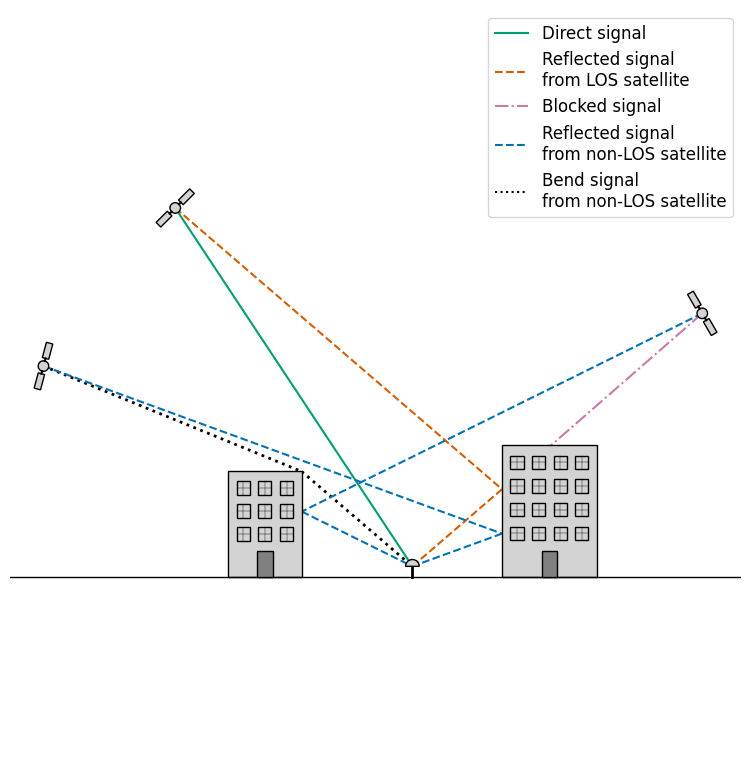

In [ ]:
receiver_left = Receiver(position=(5,2),antenna_height=2)

building_left = Building(position=(-30,0), height=20, width=14)
building_right = Building(position=(22,0), height=25, width=18)

far_left_satellite = Satellite(position=(-65,40), rotation=75)
# far_left_satellite = Satellite(position=(-65,80), rotation=60)
left_satellite = Satellite(position=(-40,70), rotation=45)
right_satellite = Satellite(position=(60,50), rotation=-60)

fig, ax = plt.subplots(figsize=(8,8))

# components for figure
receiver_left.plot(ax)
building_left.plot(ax)
building_right.plot(ax)

left_satellite.plot(ax)æ
left_satellite.draw_signal(ax, receiver_left, color='#009E73', linewidth=1.5)
left_satellite.draw_signal(ax, building_right, receiver_left, color='#D55E00', linestyle='--', linewidth=1.5)

far_left_satellite.plot(ax)
far_left_satellite.draw_signal(ax, receiver_left, building_left, color='#000000', linewidth=2, linestyle=':', corner_radius=10)
far_left_satellite.draw_signal(ax, building_right, receiver_left, color='#0072B2', linewidth=1.5, linestyle='--')

right_satellite.plot(ax)
right_satellite.draw_signal(ax, receiver_left, building_right, color='#CC79A7', linestyle='-.', linewidth=1.5)
right_satellite.draw_signal(ax, building_left, receiver_left, color='#0072B2', linestyle='--', linewidth=1.5)

from matplotlib.pyplot import Line2D
legend_elements = [
    Line2D([0], [0], color='#009E73', linewidth=1.5, label='Direct signal'),
    Line2D([0], [0], color='#D55E00', linestyle='--', linewidth=1.5, label='Reflected signal\nfrom LOS satellite'),
    Line2D([0], [0], color='#CC79A7', linestyle='-.', linewidth=1.5, label='Blocked signal'),
    Line2D([0], [0], color='#0072B2', linestyle='--', linewidth=1.5, label='Reflected signal\nfrom non-LOS satellite'),
    Line2D([0], [0], color='#000000', linestyle=':', linewidth=1.5, label='Bend signal\nfrom non-LOS satellite'),
]

ax.legend(handles=legend_elements, loc='upper right', fontsize=12)

# static settings
plt.axhline(y=0,color='black',linewidth=1)
plt.axis('equal')
plt.tight_layout()
ax.axis('off')
plt.tick_params(left = False, right = False, labelleft = False, labelbottom = False, bottom = False) 
plt.savefig(f'note_figures/multipath_nlos_los.png')
plt.show()